# Linear Algebra

While algorithms for matrix algebra are interesting, they are bit complicated to explore for the computational section of the Mathematical Physics I course.  Here we will rely more on python packages to solve linear algebra problems. One such package that we will introduce is the scipy package, which you will rely extensivley on this module. While matrix operations like matrix multiplication and dot products will be covered, the goal here will be to build up to the method of finite differences and build the intuition on what it means when we say "d/dx" is a linear operator and solve a quantum mechanics problem using your new found computational methods in linear algebra.

Topics:
1. Multidemsional Array and Matrix Operation Basics
2. expand on this section while more topics are added

For some information in the scipy package, it was built on top of the numpy package. It is far more opitmized than numpy for scientific computing. Numpy will handle all our basic functions such as creating arrays and basic operations and scipy will handle the actual matrix algebra.

In [1]:
#as always we import numpy and matplotlib :)
import numpy as np
import matplotlib.pyplot as plt 
from scipy import linalg   #scipy is made of a lot of different modules so we want import the exact ones we want.
from scipy.linalg import eigh_tridiagonal  #test stuff ignore


## Getting Started with Multidimensional Array Basics
We will be using multidemnsional arrays to represent our matrices, so it's important to know how to work with them.
Let's construct the following matrix using a multidemnsional array:
\begin{bmatrix}
1 & 2 & 3\\
2 & 4 & 6\\
1 & 3 & 5
\end{bmatrix}

In [28]:
a = np.array([[1, 2, 3], 
              [2, 4, 6], 
              [1, 3, 5]])   ## I like to write my multidimensional arrays stacked like this to better visualize the outcome.
                            ## not needed to stack, but you should recoginize that it looks more like a matrix this way

In [29]:
a

array([[1, 2, 3],
       [2, 4, 6],
       [1, 3, 5]])

We can perform all the same operations on arrays as before, for example:

In [30]:
b = 2 * a  #every entry is multiplied by 2. Make your own coding cells and play around with it
b

array([[ 2,  4,  6],
       [ 4,  8, 12],
       [ 2,  6, 10]])

It's important to know how arrays are indexed. We can call for a specific rows like this:

In [38]:
b[2]  #again remember that counting starts from 0 so calling a[2] calls the third row of an array since 0 -> 1 -> 2

array([ 2,  6, 10])

For columns we use:

In [79]:
b[:,0]  #':' means to go across all rows but only take the 0th element (so the first column)

array([2, 4, 2])

In [80]:
b[1:,1]  # '1:'means go across the 2nd row and down. ',1' means you only want the 2nd element

array([8, 6])

In [87]:
b[1:,:2]  #'1:' means you only want the the 2nd row and down. ':2' means you only want to take 2 elements

array([[4, 8],
       [2, 6]])

In [36]:
det = np.linalg.det(b)  #determinant 
print(det)

0.0


In [41]:
c = np.array([[4, 7],
             [2, 6]])

det = np.linalg.det(c)  #determinant 
print(det)

c_inverse = np.linalg.inv(c)  #inverse

print(c_inverse)

10.000000000000002
[[ 0.6 -0.7]
 [-0.2  0.4]]


## Matrix Operations
We will perform matrix operations on the following $$ A =
\begin{bmatrix}
1 & 2 & 3\\
2 & 4 & 6\\
1 & 3 & 5
\end{bmatrix} $$

Let's imagine the following the vectors: $\vec{b_1} = \begin{bmatrix} 2 \\ 2 \\ 2 \end{bmatrix}$, $\vec{b_2} = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix} $, and $\vec{b_3} = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}$ 

Let's start defining the matrix again in a multidimensional array and our vectors which we will use one dimensional arrays :

In [143]:
#matrix A
A = np.array([[1, 2 ,3],
              [2, 4, 6],
              [1, 3, 5]])
#vectors b1, b2 ,b3
b1 = np.array([2, 2, 2])
b2 = np.array([1, 2, 3])
b3 = np.array([1, 0 , 0])

Multiply A by $\vec{b_1}$: $$ A\vec{b_1} =
\begin{bmatrix}
1 & 2 & 3\\
2 & 4 & 6\\
1 & 3 & 5
\end{bmatrix} \begin{bmatrix} 2 \\ 2 \\ 2 \end{bmatrix} = \begin{bmatrix} 12 \\ 24 \\ 18 \end{bmatrix}  $$

In [98]:
A@b1 

array([12, 24, 18])

To Transpose a matrix, $A^{T} $

In [92]:
A.T

array([[1, 2, 1],
       [2, 4, 3],
       [3, 6, 5]])

To take the dot product $\vec{b_1} \cdot \vec{b_2} $:

In [96]:
np.dot(b1, b2) #so newer version of python include the integer type of the value, you can write print() if this annoys you

np.int64(12)

To take a cross product $\vec{b_1} \times \vec{b_3}$:

In [97]:
np.cross(b1, b3)

array([ 0,  2, -2])

# Solving a System of Equations
We will be using np.linalg.solve(a,b) to solve a system of linear equations. This function computes the exact solution of a well determined nxn matrix. We will not be taking the inverse of a matrix to solve these types of problems because that is computational expensive. Suppose that we a system of equations in the form: $$x + 2y - z = 4 $$ $$2x  - z = 1 $$ $$x - 2y = -3 $$

Writen in the matrix equation form $A\vec{x}=\vec{b} $ we have:  $$
\begin{bmatrix}
1 & 2 & -1\\
2 & 0 & -1\\
2 & -2 & 0
\end{bmatrix} \begin{bmatrix} x \\ y \\ z \end{bmatrix} = \begin{bmatrix} 4 \\ 1 \\ -3 \end{bmatrix}  $$


In [23]:
#we want to solve for x. We should define A and B in terms of arrays
A = np.array([[1, 2, -1],
              [2, 0, -1],
              [2, -2, 0]])
b= np.array([4, 1, -3])
x = np.linalg.solve(A,b)
x

array([ 0. ,  1.5, -1. ])

In [31]:
# we can easily verify that x is a solution by multiplying the matrix by x
print("x = ", A@x  )

x =  [ 4.  1. -3.]


## Problem 1 - Parabolic Interpolation

Parabolic interpolation: Let's say we need to fit a parabola in the form $f(x) = ax^2 + bx + c $ to three points $(x_1, f(x_1))$, $(x_2, f(x_2))$, $(x_3, f(x_3))$. We can rewrite this problem as a system of linear equations with three unknowns a, b, and c: 
$$ ax_1^2 + bx_1 + c = f(x_1) $$
$$ ax_2^2 + bx_2 + c = f(x_2) $$
$$ ax_3^2 + bx_3 + c = f(x_3) $$ which in matrix form is :

$$
\begin{bmatrix}
x_1^2 & x_1 & 1\\
x_2^2 & x_2 & 1\\
x_3^2 & x_3 & 1
\end{bmatrix} \begin{bmatrix} a \\ b \\ c \end{bmatrix} = \begin{bmatrix} f(x_1) \\ f(x_2) \\ f(x_3) \end{bmatrix}  $$
Let's say we have three specific points of data: (0.5, 2), (1, 1) and (4,8). The matrix then becomes:
$$
\begin{bmatrix}
0.25 & 0.5 & 1\\
1 & 1 & 1\\
16 & 4 & 1
\end{bmatrix} \begin{bmatrix} a \\ b \\ c \end{bmatrix} = \begin{bmatrix} 2 \\ 1 \\ 8 \end{bmatrix}  $$
Solve the matrix, plot the function you get from solving, and plot the points.


In [44]:
A = np.array([[0.25, 0.5, 1],
          [1,      1, 1],
          [16,     4, 1]])

b = np.array([2, 1 ,8])
x = np.linalg.solve(A, b)
print(x)
print("a = ", x[0], "b = ", x[1], "c = ", x[2])

[ 1.23809524 -3.85714286  3.61904762]
a =  1.2380952380952381 b =  -3.857142857142857 c =  3.619047619047619


So know we have oour coefficients. We can say $f(x) \approx 1.238095x^2 - 3.857143x + 3.619048$

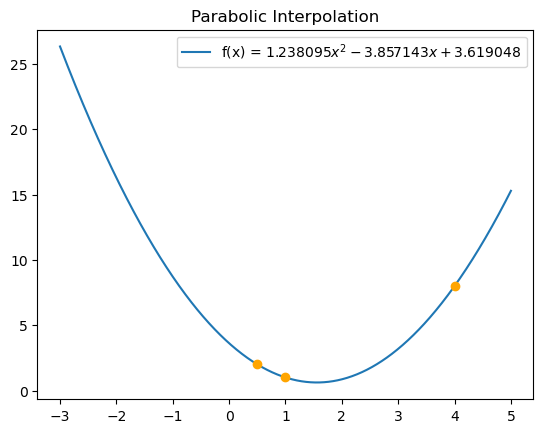

In [71]:
x = np.linspace(-3, 5, 1000)
y = 1.238096 * x **2 - 3.857143 * x + 3.619048
plt.plot(x,y, label="f(x) = $1.238095x^2 - 3.857143x + 3.619048$")
plt.title('Parabolic Interpolation')
plt.legend()
plt.plot(0.5, 2, 'o', color = 'orange')  
plt.plot(1, 1, 'o', color = 'orange')
plt.plot(4, 8, 'o', color = 'orange')

# Visualizing Matrix Transformations
It is my belief that any good course in linear algebra will show you graphically what you are doing when you apply a transformation. Mathematical Physics 1 is not a course in linear algebra, so it's difficult to spend a lot of time understanding the mathematics. Here are some tools that will better allow you to understand what it means to apply a transformation.

A matrix can transform vectors. Let's imagine the following matrix: $$ A =
\begin{bmatrix}
2 & 0 \\
1 & 4 
\end{bmatrix} $$ and vector: $$\vec{v} = \begin{bmatrix} 1 \\ 1 \end{bmatrix} $$ Let's see how v compares to Av:

In [76]:
A = np.array([[2, 0], 
             [1, 4]])
v = np.array([1, 1])

Av = A@v #here is our transformation
print("v =", v)
print("A v =", Av)

v = [1 1]
A v = [2 5]


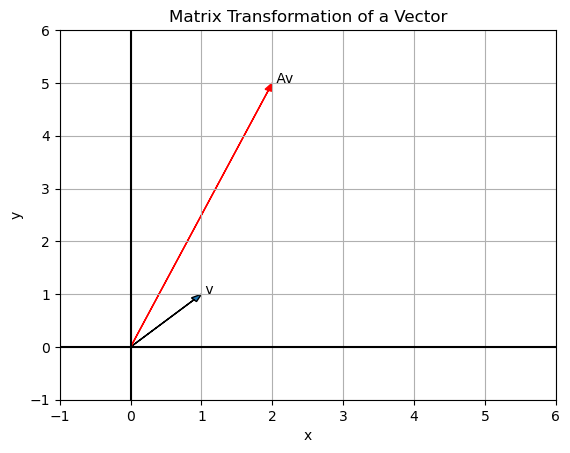

In [6]:
#plotting vectors

#plt.arrow(x, y, change in x, change in y)
plt.arrow(0, 0, v[0], v[1], head_width=0.1, length_includes_head=True)
plt.text(v[0], v[1], " v")

plt.arrow(0, 0, Av[0], Av[1], color = 'red', head_width=0.1, length_includes_head=True)
plt.text(Av[0], Av[1], " Av")

#this makes axis more visible
plt.axhline(0, color="black",)
plt.axvline(0, color="black",)

plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Matrix Transformation of a Vector")
plt.grid()
plt.show()

The rotation matrix: $$ R = \begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix} $$
Let's see what happens when $\theta = \pi/4 $ using $\vec{v} = \begin{bmatrix} 3 \\ 0 \end{bmatrix} $

In [133]:
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])
v = np.array([3, 0])

Rv = R@v

print("v = ", v)
print("Rotated v = ", Rv)

v =  [3 0]
Rotated v =  [2.12132034 2.12132034]


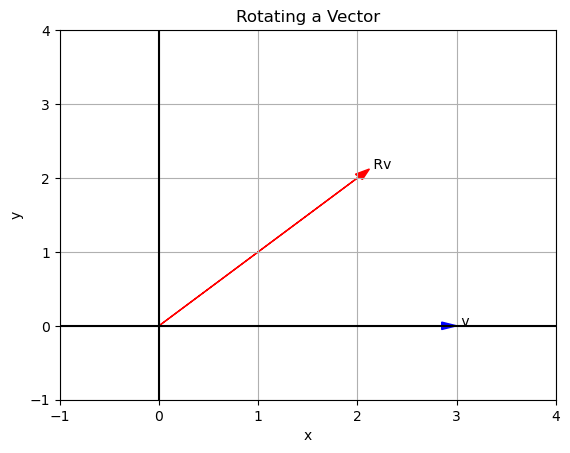

In [134]:
#plt.arrow(x, y, change in x, change in y)
plt.arrow(0, 0, v[0], v[1], color = 'blue', head_width=0.1, length_includes_head=True)
plt.text(v[0], v[1], " v")

plt.arrow(0, 0, Rv[0], Rv[1], color = 'red', head_width=0.1, length_includes_head=True)
plt.text(Rv[0], Rv[1], " Rv")   #there is a funciton called quiver() for vectors. It was giving me issues with scalin

#this makes axis more visible
plt.axhline(0, color="black",)
plt.axvline(0, color="black",)

plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Rotating a Vector")
plt.grid()
plt.show()

We can see that the vector was rotated counterclockwise

## Problem: Rotate the same vector $\vec{v}$ by $\pi/2 $
$$ R = \begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix} $$ 
$$\vec{v} = \begin{bmatrix} 3 \\ 0 \end{bmatrix} $$

In [135]:
theta = np.pi / 2  #change this
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])
v = np.array([3, 0])

Rv = R@v

print("v = ", v)
print("Rotated v = ", Rv)

v =  [3 0]
Rotated v =  [1.8369702e-16 3.0000000e+00]


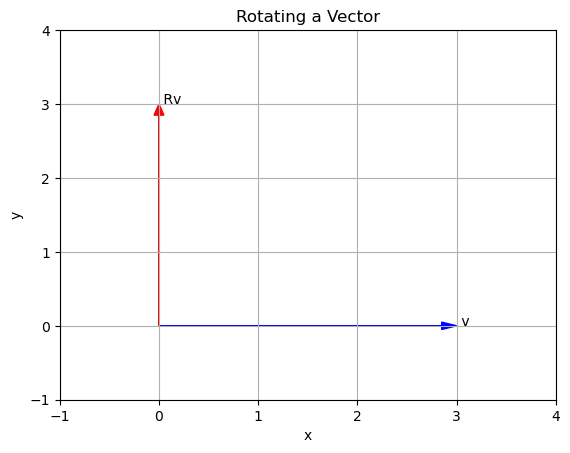

In [136]:
plt.arrow(0, 0, v[0], v[1], color = 'blue', head_width=0.1, length_includes_head=True)
plt.text(v[0], v[1], " v")

plt.arrow(0, 0, Rv[0], Rv[1], color = 'red', head_width=0.1, length_includes_head=True)
plt.text(Rv[0], Rv[1], " Rv")

plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Rotating a Vector")
plt.grid()
plt.show()

# Eigenvalues and Eigenvectors

An eigenvector is a vector whose direction is unchanged or reversed when a linear transformation is applied and is scaled by some factor $\lambda$. $$A\vec{v} = \lambda\vec{v} $$ Where $\vec{v}$ is the eigenvector and $\lambda$ is the eigenvalue.

In [172]:
A = np.array([[2, 1],
              [1, 2]])

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print("Eigenvectors:")
print(eigenvectors)

Eigenvalues:
[3. 1.]
Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


Your eigenvectors are the columns, so in order to get a specific eigenvector you have to use [:,0]

In [173]:
v1 = eigenvectors[:,0]
v2 = eigenvectors[:,1]

print("First eigenvector:", v1)
print("Second eigenvector:", v2)

First eigenvector: [0.70710678 0.70710678]
Second eigenvector: [-0.70710678  0.70710678]


We can easily check our eigenvectors:

In [174]:
#checking the first eigenvector:
lambda1 = eigenvalues[0] #or you can just put the direct value.
v1 = eigenvectors[:,0]  #this is already saved but for clarity on how we are checking them

print("Av1 = ", A@v1)
print("lambda * v1 = ", lambda1 * v1)  

Av1 =  [2.12132034 2.12132034]
lambda * v1 =  [2.12132034 2.12132034]


Notice how the same value is outputed. 

check the second eigenvector yourself:

In [175]:
lambda2 = eigenvalues[1] #I think this should be another problem for the students
v2 = eigenvectors[:,1]  

print("Av2 = ", A@v2)  
print("lambda * v2 = ", lambda2 * v2)   

Av2 =  [-0.70710678  0.70710678]
lambda * v2 =  [-0.70710678  0.70710678]


# Problem: Coupled Oscillators and Modes
In the book by Boas on Applications of Diagonalization, Example 3 talks about finding the charasteristic vibration freqeuencies for a system of masses and springs shown  on page 165. |---{}{}---o---{}{}---0---{}{}---|  where the o are masses and the {}{} are springs and | are walls and the equations of motion are: $$-m\omega^2 x_1 = -2kx_1 + kx_2$$ $$-m\omega^2 x_2 = kx_1 - 2kx_2 $$
Dividing by m and turning it into matrix form we have: $$\lambda \vec{x} = \begin{bmatrix}
2 & -1 \\
-1 & 2
\end{bmatrix}\vec{x}\space \text{  with } \lambda = \frac{m\omega^2}{k}$$ 


In [11]:
m = 1.0  #you can set a lot of units to 1 to simplify calculations 
k = 1.0

K = np.array([[2, -1],   #here is our coupling matrix 
              [-1, 2]])

eigenvalues, eigenvectors = np.linalg.eig(K)

print("Eigenvalues:")
print(eigenvalues)

print("Eigenvectors:")
print(eigenvectors)

Eigenvalues:
[3. 1.]
Eigenvectors:
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


We see we have eigenvalues of $\lambda = 1 \space\text{and}\space \lambda = 3 $ so our charaterstic frequencies are $$\omega_1 = \sqrt{\frac{k}{m}} \space\text{     and     }\space \omega_2 = \sqrt{\frac{3k}{m}} $$

In [12]:
omega = np.sqrt((k/m) * eigenvalues)

print("Angular frequencies:")
print(omega)

Angular frequencies:
[1.73205081 1.        ]


In [8]:
for i in range(2):  #we are just shoing the results put together
    print(f"Mode {i+1}:") #f here allows what's inside {} to be evulated by the loop instead of just being a string
    print("eigenvalue =", eigenvalues[i])
    print("omega =", omega[i])
    print("eigenvector =", eigenvectors[:, i])
    print()

Mode 1:
eigenvalue = 3.0
omega = 1.7320508075688772
eigenvector = [ 0.70710678 -0.70710678]

Mode 2:
eigenvalue = 1.0
omega = 1.0
eigenvector = [0.70710678 0.70710678]



We can see the modes are (1, -1) or (1,1) with the Mode 1 having the masses move in opposite directions and Mode 2 having the masses move together.


## Fitting Data and Least Squares
We know Hooke's law states F = -kx. In a labatory setting, real data will have some noise or error. $$F = -kx + b + noise$$ We can learn k and b using linear algebra with the matrix equation $$\vec{F} = X\vec{w} $$ where $$X = \begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
x_3 & 1 \\
\cdots & \cdots \\
x_N & 1
\end{bmatrix} $$ The second column is all 1's so that it doesn't scale b in: $$\vec{w} = \begin{bmatrix} k \\ b \end{bmatrix} $$

[0.         0.05263158 0.10526316 0.15789474 0.21052632 0.26315789
 0.31578947 0.36842105 0.42105263 0.47368421 0.52631579 0.57894737
 0.63157895 0.68421053 0.73684211 0.78947368 0.84210526 0.89473684
 0.94736842 1.        ]


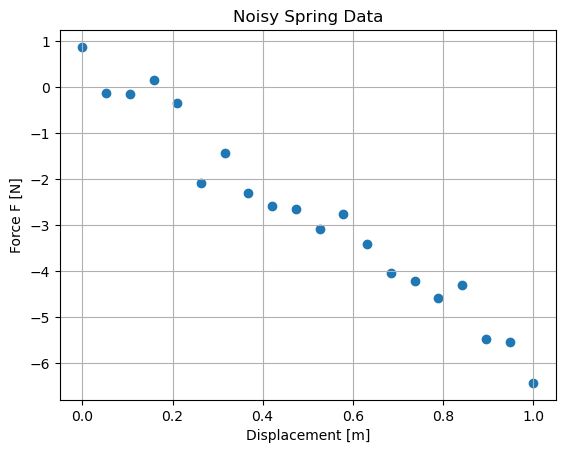

In [13]:
np.random.seed(0)  #sets up a random number generator whose outputs are predictable

k_true = 12.0
b_true = 0.5

x = np.linspace(0, 1, 20)
noise = np.random.normal(0, 0.5, len(x))  #.normal parts makes the generating numbers
                                          #follow a gaussian distribution
                                          #so we setup up an array of numbers x and then
                                          #filled an array noise with random numbers
F = -k_true * x * b_true + noise

print(x)
plt.scatter(x, F)
plt.xlabel("Displacement [m]")
plt.ylabel("Force F [N]")
plt.title("Noisy Spring Data")
plt.grid()
plt.show()

It almost looks like data you would get in a laboratory setting. We can make a matrix out of this data.

We still want to model F = kx + b, so for the matrix we $$X = \begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\cdots & \cdots \\
x_N & 1
\end{bmatrix} $$

In [17]:
X = np.column_stack([x, np.ones(len(x))]) #this stacks the different arrays into columns
                                          #np.ones like np.zero filles the array with 1s
print(X)

[[0.         1.        ]
 [0.05263158 1.        ]
 [0.10526316 1.        ]
 [0.15789474 1.        ]
 [0.21052632 1.        ]
 [0.26315789 1.        ]
 [0.31578947 1.        ]
 [0.36842105 1.        ]
 [0.42105263 1.        ]
 [0.47368421 1.        ]
 [0.52631579 1.        ]
 [0.57894737 1.        ]
 [0.63157895 1.        ]
 [0.68421053 1.        ]
 [0.73684211 1.        ]
 [0.78947368 1.        ]
 [0.84210526 1.        ]
 [0.89473684 1.        ]
 [0.94736842 1.        ]
 [1.         1.        ]]


# Finding Best Fit parameters
Since the data has noise, we cannot find an exact solution, instead we approximate it using the method of least-squares where $$X\vec{w} \approx \vec{F} $$

In [18]:
# w are the optimals weights to find a solution
# residuals is the error
# rank of the matrix
#singular_values means variance
#rcond = none -->this protects you from floating point errors

w, residuals, rank, singular_values = np.linalg.lstsq(X, F, rcond=None)

k_fit = w[0]
b_fit = w[1]

print("Best-fit k =", k_fit)
print("Best-fit b =", b_fit)

Best-fit k = -6.568612927588494
Best-fit b = 0.5689737602670645


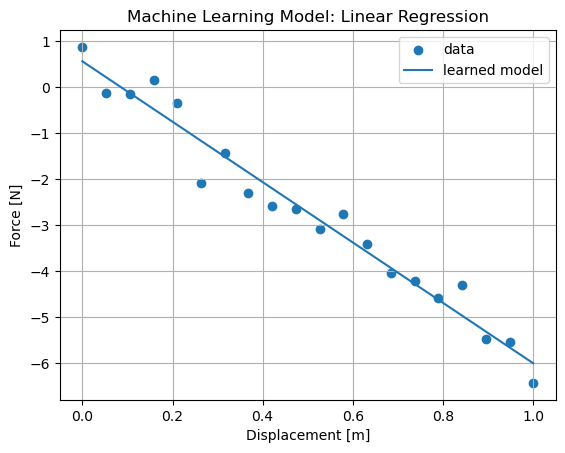

In [22]:
F_predicted = X @ w

plt.scatter(x, F, label="data")
plt.plot(x, F_predicted, label="learned model")

plt.xlabel("Displacement [m]")
plt.ylabel("Force [N]")
plt.title("Machine Learning Model: Linear Regression")
plt.legend()
plt.grid()
plt.show()

In [24]:
mse = np.mean((F - F_predicted)**2)  

print("Mean squared error =", mse)

Mean squared error = 0.15092316391922608


# Optional : Simple Introduction to Finite difference Methods
We know that $\frac{d}{dx}$ is a linear operator or in other words a linear function that performs some instruction on whatever follows it such as a number, vector, or another function. 

We can also discretize a function with a an N number of points and represent it using a vector : $$\vec{f} = \begin{bmatrix} f(x_1) \\ f(x_2) \\ f(x_3) \\ \cdots \\ f(x_n) \end{bmatrix} $$
If we had an infinite amount of points, we would have the function but with only an N number of points we can represent a discretize form of the function

So I want to explore if we can also represent the derivative operator as a matrix operator that acts on a function that we represent as a vector. Numerically we can represent the second deriative with the following: $$ f''(x) \approx \frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{h^2}
 $$ where h represents the spacing between the points or in matrix form for 4 points:

$$f''(x) = \frac{1}{h^2}
\begin{bmatrix}
-2 & 1 & 0 & 0\\
 1 & -2 & 1 & 0\\
0 & 1 & -2 & -1 \\
0 & 0 & 1 & -2 
\end{bmatrix} \begin{bmatrix} f_1 \\ f_2 \\ f_3 \\ f_4 \end{bmatrix}   $$

In [33]:
#obviously we want more than 4 points so let's build a derivative matrix of 100 points
n = 100
x = np.linspace(0, 1, n)
h = x[1] - x[0] #again this is the spacing between points

D_2 = np.zeros((n,n)) #builds an nxn matrix and fills it iwth zeroes

for i in range(1, n-1):
    D_2[i, i-1] = 1
    D_2[i, i] = -2
    D_2[i, i+1] =1

D_2 = D_2 / h**2

print(D_2)

[[     0.      0.      0. ...      0.      0.      0.]
 [  9801. -19602.   9801. ...      0.      0.      0.]
 [     0.   9801. -19602. ...      0.      0.      0.]
 ...
 [     0.      0.      0. ... -19602.   9801.      0.]
 [     0.      0.      0. ...   9801. -19602.   9801.]
 [     0.      0.      0. ...      0.      0.      0.]]


Notice how the first and last rows are all zeroes. These are our boundary conditions.

Let's test this with $$f(x) = \sin(\pi x) $$ where $$f''(x) = -\pi^2 \sin(\pi x) $$

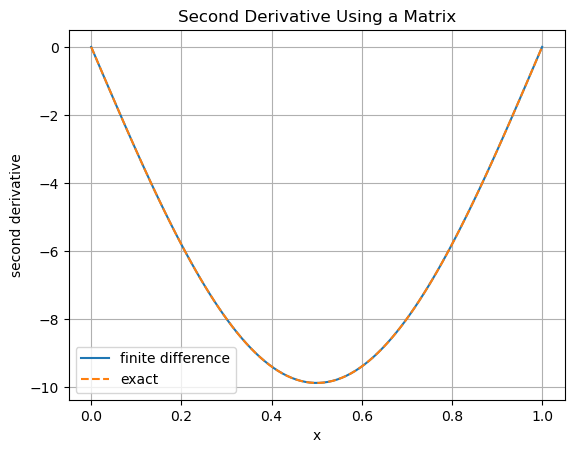

In [37]:
f = np.sin(np.pi * x)

second_derivative = D_2 @ f
exact_derivative = -np.pi**2 * np.sin(np.pi * x)

plt.plot(x, second_derivative, label="finite difference")
plt.plot(x, exact_derivative, "--", label="exact")

plt.xlabel("x")
plt.ylabel("second derivative")
plt.title("Second Derivative Using a Matrix")
plt.legend()
plt.grid()
plt.show()